# Verifying the velocity dispersion of Boo III
Can we reproduce my velocity dispersion using Simon's code and emcee (instead of my code and Turing.jl)?

The velocity dispersion of Boo III is tricky. We have < 20 stars total, with inhomegenous uncertainties and relatively large errors. As such, measurements in literature have ranged from ``\sigma_v \sim 14\,``km/s (@carlin+2009) to ``\sigma_v \sim 5`` km/s (@geha+2026). 

Using @geha+2026's published members, I recover a velocity dispersion about 1 sigma higher. As such, I would like to verify against an independent method.

Unfortunantely, this code (only modifying the prior) results in the same results. As such, I conclude that the Geha+2026 derived velocity dispersions are likely not consistent with their reported measurements.


In [1]:
import numpy as np

import corner
import emcee
from astropy.io import fits

import matplotlib.pyplot as plt

In [2]:
import arya

In [3]:
sig_max = 30 # 10 for unions 1


In [4]:
def make_prior(mu_min, mu_max, sig_max=30):
    def log_vprior(params):
        mu, sig = params
        if mu_min < mu < mu_max and 0.0 < sig < sig_max:  ### set REASONABLE flat priors around the expected mean velocity
            return 0.0
        return -np.inf
    return log_vprior

In [37]:
def log_like(params, obs, unc, N):
    """
    Log likelihood function for the product of two normally distributed distributions.
    Parameters that will be maximized: true mean (mu), instrinsic dispersion, (sig)
    Parameters passed in: observed value (obs), measured uncertainty (unc)
    """
    mu, sig = params
    return -0.5*np.sum(np.log(unc**2 + sig**2)) - 0.5*np.sum((obs-mu)**2/(unc**2 + sig**2)) - N/2*np.log(2*np.pi)
    
def log_vprior(params):
    mu, sig = params
    if 70 < mu < 100 and 0.0 < sig < 10.:  ### set REASONABLE flat priors around the expected mean velocity
        return 0.0
    return -np.inf

def log_vprob(params, obs, unc, N):
    lp = log_vprior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_like(params, obs, unc, N)

# Unions 1

In [ ]:
obs = dmems['v']
unc = dmems['v_err']
N = len(obs)

nwalkers = 64

mu_walk = np.random.uniform(70, 100, size=nwalkers)
sig_walk = np.random.uniform(0, 10, size=nwalkers)

p0 = np.array([mu_walk, sig_walk]).T
ndim = 2

samplerv = emcee.EnsembleSampler(
    nwalkers, ndim, log_vprob, args=(obs, unc, N)
)

samplerv.run_mcmc(p0, 10000, progress=True);

In [10]:
#Corner plot
flat_samplesv = samplerv.get_chain(discard=2000, flat=True)
labels = [r"$\langle v_{\odot}\rangle$ (km s$^{-1}$)", r"$\sigma_v$ (km s$^{-1}$)"]
label_unit = r"km s$^{-1}$"

value = np.median(flat_samplesv, axis=0)
vels = np.quantile(flat_samplesv.T[0], [0.16, 0.50, 0.84])
disps = np.quantile(flat_samplesv.T[1], [0.16, 0.50, 0.84])

hist_kwargs = {'histtype':'stepfilled', 'alpha':1, 'ec':'xkcd:cherry red', 'color':'xkcd:pale rose', 'lw':2, 'alpha':1}

fig = corner.corner(
    flat_samplesv, labels=labels, quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, color='k', title_fmt='.1f', labelpad=-0.1, hist_kwargs=hist_kwargs
)


NameError: name 'samplerv' is not defined

# Bootes III

In [38]:
import pandas as pd

In [39]:

env = %env
dwarfs_root = "~/data/dwarfs/"

In [40]:
rvs_deimos = pd.read_csv(dwarfs_root + "/observations/bootes3/data/deimos_velocities.txt", sep=" +", skiprows=36, header=0,
	names=["system", "ra", "dec", "r_mag", "g_r", "nmask", "texp", "SN", "RV",
			"RV_err", "WECaT", "EWCaT_err", "FE_H", "FE_H_err", "Var", "P_SAT_deimos"]
					)

/tmp/ipykernel_1766263/3746670299.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  rvs_deimos = pd.read_csv(dwarfs_root + "/observations/bootes3/data/deimos_velocities.txt", sep=" +", skiprows=36, header=0,


In [41]:
filt = (rvs_deimos.system == "Boo3") & (rvs_deimos.P_SAT_deimos > 0.5) & (rvs_deimos.Var <= 0)

boo3_deimos = rvs_deimos[filt]

boo3_deimos

,system,ra,dec,r_mag,g_r,nmask,texp,SN,RV,RV_err,WECaT,EWCaT_err,FE_H,FE_H_err,Var,P_SAT_deimos
462,Boo3,209.159583,26.872889,19.6,0.50,1,3600,18.7,189.72,2.05,2.55,0.31,-2.29,0.21,-999,0.763
485,Boo3,209.322583,26.850222,20.2,0.32,1,3600,3.7,205.20,14.27,-999.00,-999.00,-999.00,-999.00,-999,0.608
489,Boo3,209.310292,26.851306,21.1,0.63,2,3600,3.8,196.68,6.75,-999.00,-999.00,-999.00,-999.00,-999,0.525
500,Boo3,209.500250,26.835861,20.5,0.45,2,4500,12.1,179.19,8.88,1.78,0.61,-2.63,0.48,-999,0.613
518,Boo3,209.222196,26.465492,18.6,0.42,1,4500,12.0,191.83,4.86,1.65,0.50,-999.00,-999.00,-999,0.802
525,Boo3,209.331954,26.573631,19.3,-0.21,1,4500,6.6,185.89,9.01,6.98,1.64,-999.00,-999.00,-999,0.753
560,Boo3,210.051450,26.637247,18.9,-0.09,1,2470,18.2,192.98,2.64,5.52,0.43,-999.00,-999.00,-999,0.798
586,Boo3,208.574058,26.571456,19.4,0.50,1,2700,16.0,191.67,2.46,1.71,0.59,-2.82,0.49,-999,0.901
592,Boo3,208.569800,26.788653,20.0,0.48,1,2700,8.7,181.57,5.59,1.78,0.46,-2.69,0.37,-999,0.779
600,Boo3,208.525358,26.764431,21.1,0.46,1,2700,4.0,175.11,7.80,6.58,1.78,-999.00,-999.00,-999,0.725


(array([1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 2.,
        0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 2., 1., 1., 0.,
        0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([170.43  , 171.1254, 171.8208, 172.5162, 173.2116, 173.907 ,
        174.6024, 175.2978, 175.9932, 176.6886, 177.384 , 178.0794,
        178.7748, 179.4702, 180.1656, 180.861 , 181.5564, 182.2518,
        182.9472, 183.6426, 184.338 , 185.0334, 185.7288, 186.4242,
        187.1196, 187.815 , 188.5104, 189.2058, 189.9012, 190.5966,
        191.292 , 191.9874, 192.6828, 193.3782, 194.0736, 194.769 ,
        195.4644, 196.1598, 196.8552, 197.5506, 198.246 , 198.9414,
        199.6368, 200.3322, 201.0276, 201.723 , 202.4184, 203.1138,
        203.8092, 204.5046, 205.2   ]),
 <BarContainer object of 50 artists>)

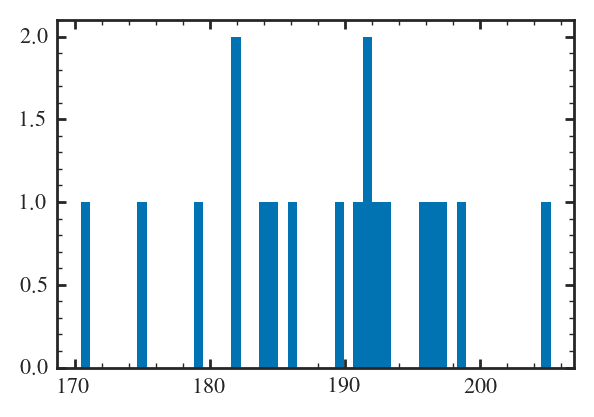

In [43]:
plt.hist(boo3_deimos.RV)

In [44]:
sig_max = 30
mu_min = 170
mu_max = 210
def log_vprior(params):
    mu, sig = params
    if mu_min < mu < mu_max and 0.0 < sig < sig_max:  ### set REASONABLE flat priors around the expected mean velocity
        return 0.0
    return -np.inf


def log_vprob(params, obs, unc, N):
    lp = log_vprior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_like(params, obs, unc, N)

In [48]:
obs = boo3_deimos.RV.to_numpy()
unc = ((boo3_deimos.RV_err.to_numpy() * 1.4)**2 + 1.1**2)**0.5
N = len(obs)

nwalkers = 64

mu_walk = np.random.uniform(mu_min, mu_max, size=nwalkers)
sig_walk = np.random.uniform(0, sig_max, size=nwalkers)

p0 = np.array([mu_walk, sig_walk]).T
ndim = 2

samplerv = emcee.EnsembleSampler(
    nwalkers, ndim, log_vprob, args=(obs, unc, N)
)

samplerv.run_mcmc(p0, 10_000, progress=True);

100%|██████████| 10000/10000 [00:09<00:00, 1053.65it/s]


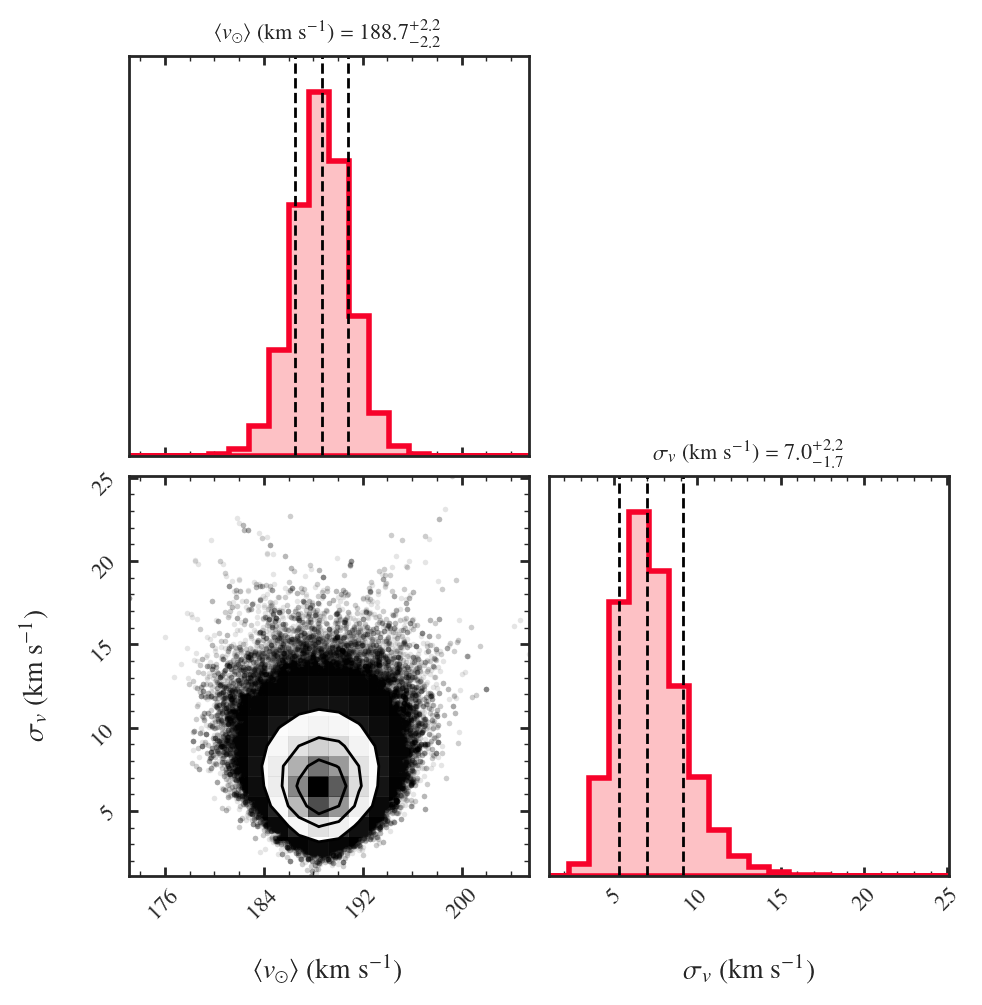

In [49]:
#Corner plot
flat_samplesv = samplerv.get_chain(discard=500, flat=True)
labels = [r"$\langle v_{\odot}\rangle$ (km s$^{-1}$)", r"$\sigma_v$ (km s$^{-1}$)"]
label_unit = r"km s$^{-1}$"

value = np.median(flat_samplesv, axis=0)
vels = np.quantile(flat_samplesv.T[0], [0.16, 0.50, 0.84])
disps = np.quantile(flat_samplesv.T[1], [0.16, 0.50, 0.84])

hist_kwargs = {'histtype':'stepfilled', 'alpha':1, 'ec':'xkcd:cherry red', 'color':'xkcd:pale rose', 'lw':2, 'alpha':1}

fig = corner.corner(
    flat_samplesv, labels=labels, quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, color='k', title_fmt='.1f', labelpad=-0.1, hist_kwargs=hist_kwargs
)
